<a href="https://colab.research.google.com/github/SathishKentState/Sathish-Babu-Nuthi_Advanced-Machine-Learning/blob/main/Sathish__Babu__Nuthi__BA74067Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, pathlib
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory


base_dir = pathlib.Path('/content/drive/MyDrive/Advanced_ML')

Mounted at /content/drive


In [ ]:

zip_path = base_dir / "train.zip"


!unzip -q "{zip_path}" -d "/content/"

print("Unzip finished! The images are now sitting on the high-speed local drive.")

Unzip finished! The images are now sitting on the high-speed local drive.


In [ ]:
import shutil

original_dir = pathlib.Path('/content/train')
new_base_dir = pathlib.Path('/content/cats_vs_dogs_small')


def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):

        dir = new_base_dir / subset_name / category
        os.makedirs(dir, exist_ok=True)


        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]

        for fname in fnames:
            src = original_dir / fname
            dst = dir / fname
            if os.path.exists(src):
                shutil.copyfile(src=src, dst=dst)


make_subset("train", start_index=0, end_index=500)


make_subset("validation", start_index=500, end_index=750)


make_subset("test", start_index=750, end_index=1250)

print("Folders are ready! Your data is organized locally.")

Folders are ready! Your data is organized locally.


1. Consider the Cats & Dogs example. Start initially with a training sample of 1000, avalidation sample of 500, and a test sample of 500 (like in the text). Use any techniqueto reduce overfitting and improve performance in developing a network that you trainfrom scratch. What performance did you achieve?

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory


train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)


validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)


test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 1000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers


inputs = keras.Input(shape=(180, 180, 3))


x = layers.Rescaling(1./255)(inputs)


x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)


x = layers.Flatten()(x)


outputs = layers.Dense(1, activation="sigmoid")(x)


model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:

model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])


model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss")
]


history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 214ms/step - accuracy: 0.5160 - loss: 0.6972 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5330 - loss: 0.7005 - val_accuracy: 0.5100 - val_loss: 0.6909
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5460 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6908
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - accuracy: 0.5880 - loss: 0.6875 - val_accuracy: 0.5000 - val_loss: 0.8450
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.5850 - loss: 0.6650 - val_accuracy: 0.5600 - val_loss: 0.6801
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.6460 - loss: 0.6415 - val_accuracy: 0.5100 - val_loss: 0.9312
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.6630 - loss: 0.6469 - val_accuracy: 0.5720 - val_loss: 0.7091
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.6740 - loss: 0.6107 - val_accuracy: 0.6200 

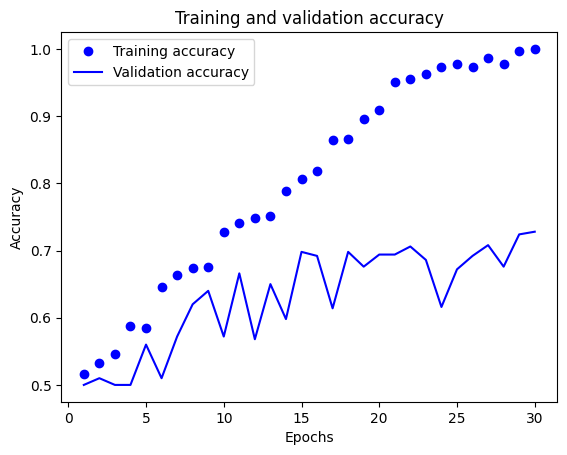

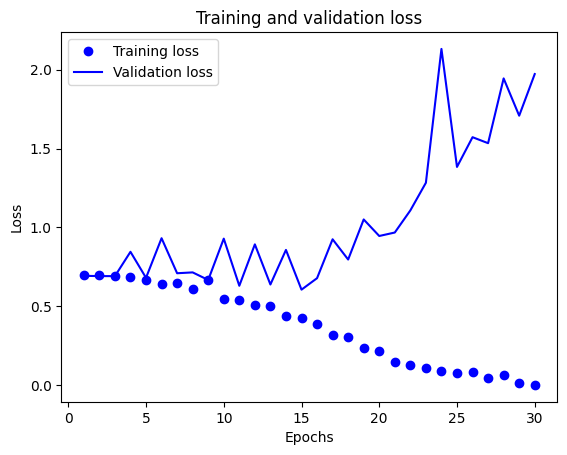

In [ ]:
import matplotlib.pyplot as plt


accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)


plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.figure()


plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:

test_model = keras.models.load_model("convnet_from_scratch.keras")


test_loss, test_acc = test_model.evaluate(test_dataset)


print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.6880 - loss: 0.6351
Test accuracy: 0.688


Technique to reduce overfitting and improve performance

In [ ]:

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)


inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)

x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)


model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

In [ ]:

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss")
]


history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.4940 - loss: 0.7083 - val_accuracy: 0.5280 - val_loss: 0.6930
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.5280 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5330 - loss: 0.6970 - val_accuracy: 0.5040 - val_loss: 0.6924
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.5420 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.7001
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5600 - loss: 0.6868 - val_accuracy: 0.5000 - val_loss: 0.7231
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5860 - loss: 0.6782 - val_accuracy: 0.5060 - val_loss: 0.7163
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.6070 - loss: 0.6652 - val_accuracy: 0.5720 - val_loss: 0.6755
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6300 - loss: 0.6612 - val_accuracy: 0.

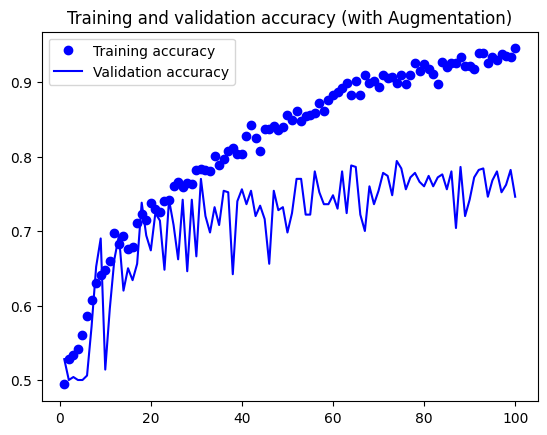

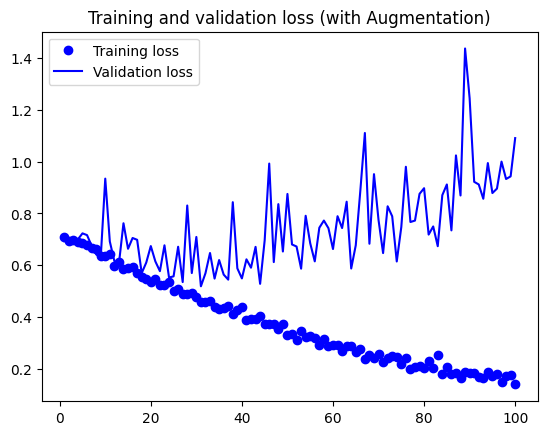

In [ ]:
import matplotlib.pyplot as plt


accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)


plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy (with Augmentation)")
plt.legend()
plt.figure()


plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss (with Augmentation)")
plt.legend()
plt.show()

In [ ]:

test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")


test_loss, test_acc = test_model.evaluate(test_dataset)


print(f"Augmented Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7640 - loss: 0.4992
Augmented Test accuracy: 0.764


Question 2: Increase your training sample size. You may pick any amount. Keep the validation and test samples the same as above. Optimize your network (again training from scratch). What performance did you achieve?

In [ ]:

import keras
from keras import layers
from tensorflow.keras.utils import image_dataset_from_directory


train_dataset_large = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_q2 = keras.Model(inputs=inputs, outputs=outputs)

model_q2.compile(loss="binary_crossentropy",
                 optimizer="rmsprop",
                 metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_large_data.keras",
        save_best_only=True,
        monitor="val_loss")
]

history_q2 = model_q2.fit(
    train_dataset_large,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Found 1000 files belonging to 2 classes.
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step - accuracy: 0.4930 - loss: 0.6982 - val_accuracy: 0.5220 - val_loss: 0.6930
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.5200 - loss: 0.6948 - val_accuracy: 0.5400 - val_loss: 0.6896
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5390 - loss: 0.7025 - val_accuracy: 0.4980 - val_loss: 0.6915
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5540 - loss: 0.6838 - val_accuracy: 0.5000 - val_loss: 1.8419
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.5920 - loss: 0.6977 - val_accuracy: 0.6040 - val_loss: 0.6647
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.6290 - loss: 0.6476 - val_accuracy: 0.5920 - val_loss: 0.6712
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.6530 - loss: 0.6292 - val_accuracy: 0.5480 - val_loss: 0.9507
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.6670

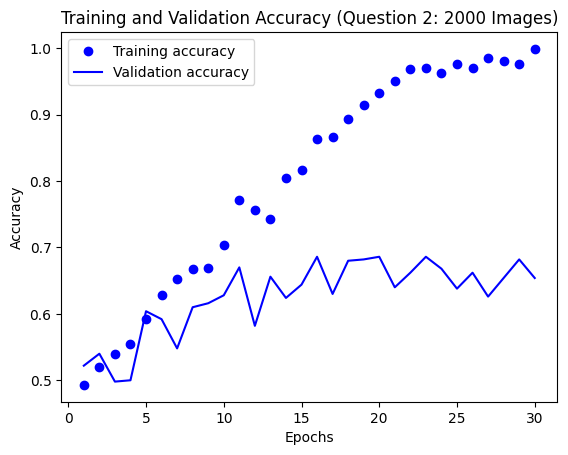

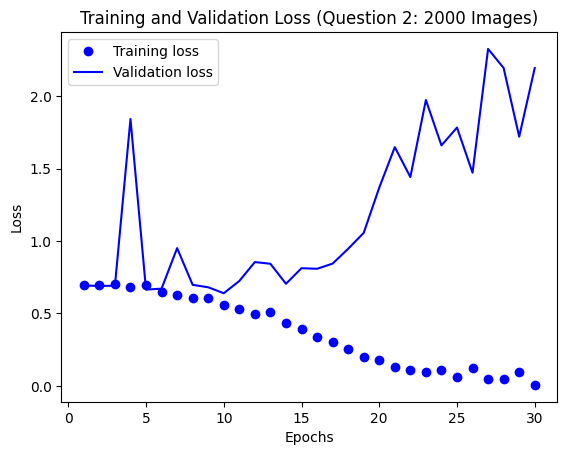

In [ ]:

import matplotlib.pyplot as plt

accuracy = history_q2.history["accuracy"]
val_accuracy = history_q2.history["val_accuracy"]
loss = history_q2.history["loss"]
val_loss = history_q2.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and Validation Accuracy (2000 Images)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and Validation Loss (2000 Images)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:

test_model_q2 = keras.models.load_model("convnet_from_scratch_large_data.keras")

test_loss, test_acc = test_model_q2.evaluate(test_dataset)

print("\n" + "="*45)

print("="*45)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.6510 - loss: 0.6417



In [ ]:

import keras
from keras import layers
from tensorflow.keras.utils import image_dataset_from_directory


make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1250)
make_subset("test", start_index=1250, end_index=1750)


train_dataset_large = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)


inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_q2 = keras.Model(inputs=inputs, outputs=outputs)

model_q2.compile(loss="binary_crossentropy",
                 optimizer="rmsprop",
                 metrics=["accuracy"])


callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_large_data.keras",
        save_best_only=True,
        monitor="val_loss")
]


history_q2 = model_q2.fit(
    train_dataset_large,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Found 2000 files belonging to 2 classes.
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.5260 - loss: 0.7159 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.5525 - loss: 0.6986 - val_accuracy: 0.5020 - val_loss: 0.6912
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5730 - loss: 0.6785 - val_accuracy: 0.5660 - val_loss: 0.6463
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.6375 - loss: 0.6345 - val_accuracy: 0.6480 - val_loss: 0.6114
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.6825 - loss: 0.5947 - val_accuracy: 0.6640 - val_loss: 0.6009
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.6985 - loss: 0.5714 - val_accuracy: 0.7780 - val_loss: 0.5005
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7175 - loss: 0.5332 - val_accuracy: 0.6960 - val_loss: 0.5542
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.74

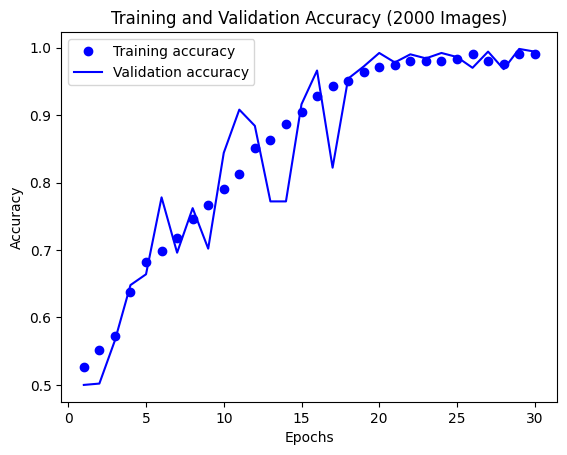

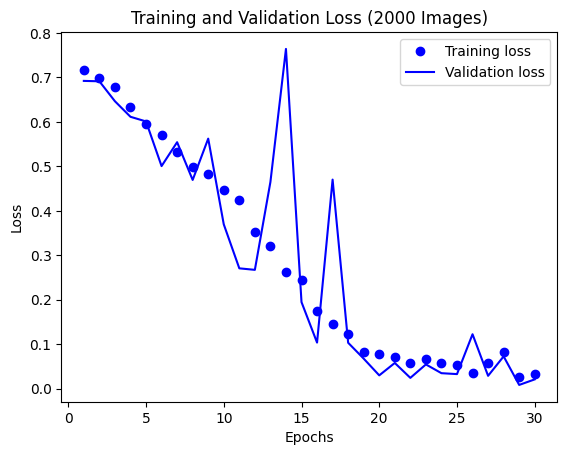

In [ ]:

import matplotlib.pyplot as plt

acc = history_q2.history["accuracy"]
val_acc = history_q2.history["val_accuracy"]
loss = history_q2.history["loss"]
val_loss = history_q2.history["val_loss"]
epochs = range(1, len(acc) + 1)


plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and Validation Accuracy (2000 Images)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()


plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and Validation Loss (2000 Images)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:

test_model_q2 = keras.models.load_model("convnet_from_scratch_large_data.keras")


test_loss, test_acc = test_model_q2.evaluate(test_dataset)





32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8570 - loss: 1.0086


3. Now change your training sample so that you achieve better performance than thosefrom Steps 1 and 2. This sample size may be larger, or smaller than those in the previoussteps. The objective is to find the ideal training sample size to get best predictionresults.

In [ ]:

make_subset("train", start_index=0, end_index=2500)

make_subset("validation", start_index=2500, end_index=3000)
make_subset("test", start_index=3000, end_index=3500)

train_dataset_q3 = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)



Found 5000 files belonging to 2 classes.


In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model_q3.keras",
        save_best_only=True,
        monitor="val_loss")
]

history_q3 = model_q2.fit(
    train_dataset_q3,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)



Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9794 - loss: 0.0738 - val_accuracy: 0.9960 - val_loss: 0.0192
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9846 - loss: 0.0513 - val_accuracy: 0.9900 - val_loss: 0.0916
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9848 - loss: 0.0544 - val_accuracy: 0.9900 - val_loss: 0.0192
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9906 - loss: 0.0386 - val_accuracy: 0.9980 - val_loss: 0.0135
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9840 - loss: 0.0619 - val_accuracy: 0.9780 - val_loss: 0.1139
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9862 - loss: 0.0622 - val_accuracy: 0.9920 - val_loss: 0.0240
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9862 - loss: 0.0653 - val_accuracy: 0.9900 - val_loss: 0.0494
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.9878 - loss: 0.0459 - val_ac

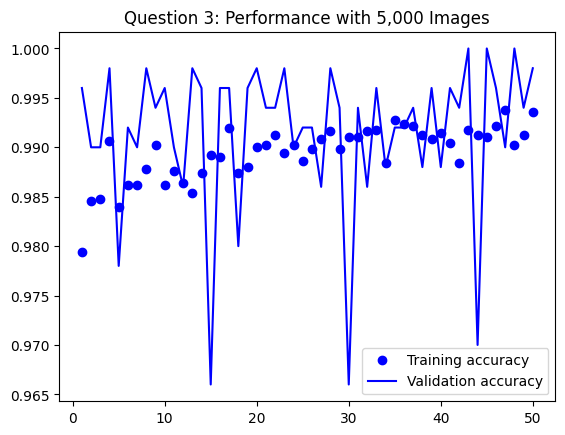

In [ ]:

import matplotlib.pyplot as plt

acc = history_q3.history["accuracy"]
val_acc = history_q3.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Question 3: Performance with 5,000 Images")
plt.legend()
plt.show()

In [ ]:

best_model_q3 = keras.models.load_model("best_model_q3.keras")
test_loss, test_acc = best_model_q3.evaluate(test_dataset)

print(f"STEP 3 ACCURACY (5,000 images): {test_acc:.3f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9970 - loss: 0.0270
STEP 3 ACCURACY (5,000 images): 0.997


4. Repeat Steps 1-3, but now using a pretrained network. The sample sizes you use inSteps 2 and 3 for the pretrained network may be the same or different from those usingthe network where you trained from scratch. Again, use any and all optimizationtechniques to get best performance.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory

def build_pretrained_model():

    data_augmentation = keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.2),
        ]
    )


    conv_base = keras.applications.VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(180, 180, 3))


    conv_base.trainable = False

    inputs = keras.Input(shape=(180, 180, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.vgg16.preprocess_input(x)
    x = conv_base(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)

    model.compile(loss="binary_crossentropy",
                  optimizer="rmsprop",
                  metrics=["accuracy"])
    return model



sample_sizes = [1000, 2000, 5000]
results_summary = {}

for size in sample_sizes:
    print(f"\n--- Running Pretrained Model with {size} Images ---")

    end_idx = size // 2
    make_subset("train", start_index=0, end_index=end_idx)

    make_subset("validation", start_index=2500, end_index=3000)
    make_subset("test", start_index=3000, end_index=3500)


    train_ds = image_dataset_from_directory(new_base_dir / "train", image_size=(180, 180), batch_size=32)
    val_ds = image_dataset_from_directory(new_base_dir / "validation", image_size=(180, 180), batch_size=32)
    test_ds = image_dataset_from_directory(new_base_dir / "test", image_size=(180, 180), batch_size=32)

    model = build_pretrained_model()
    filepath = f"pretrained_{size}.keras"
    callbacks = [keras.callbacks.ModelCheckpoint(filepath=filepath, save_best_only=True, monitor="val_loss")]

    history = model.fit(train_ds, epochs=20, validation_data=val_ds, callbacks=callbacks)

    best_model = keras.models.load_model(filepath)
    test_loss, test_acc = best_model.evaluate(test_ds)
    results_summary[size] = test_acc
    print(f"Final Test Accuracy for {size} images: {test_acc:.4f}")


--- Running Pretrained Model with 1000 Images ---
Found 5000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Found 3000 files belonging to 2 classes.
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.9158 - loss: 2.6734 - val_accuracy: 0.9680 - val_loss: 0.2736
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - accuracy: 0.9498 - loss: 0.4147 - val_accuracy: 0.9755 - val_loss: 0.1630
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - accuracy: 0.9508 - loss: 0.2978 - val_accuracy: 0.9795 - val_loss: 0.2439
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 141ms/step - accuracy: 0.9516 - loss: 0.3163 - val_accuracy: 0.9780 - val_loss: 0.2513
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.9614 - loss: 0.3013 - val_accuracy: 0.9760 - val_loss: 0.1224
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.9646 - loss: 0.1786 - val_accuracy: 0.9800 - val_loss: 0.1217
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 

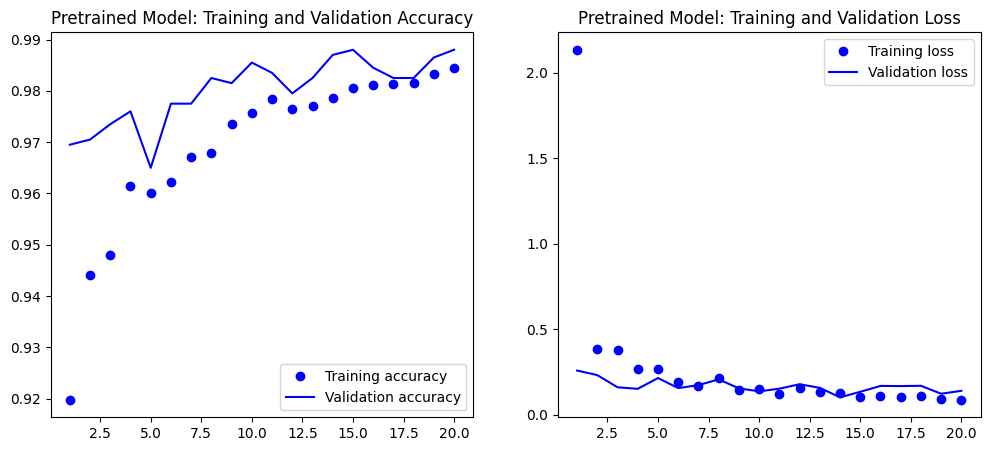

In [ ]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Pretrained Model: Training and Validation Accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Pretrained Model: Training and Validation Loss")
plt.legend()

plt.show()

In [ ]:

print("QUESTION 4: ACCURATE TEST RESULTS")
print("="*45)
for size, acc in results_summary.items():
    print(f"Sample Size {size} images: {acc:.4f} accuracy")


QUESTION 4: ACCURATE TEST RESULTS
Sample Size 1000 images: 0.9927 accuracy
Sample Size 2000 images: 0.9897 accuracy
Sample Size 5000 images: 0.9907 accuracy


**Reasoning**:
The previous command modified cell `KO8kqOgHlkku`. Now, I need to execute this modified cell to see the corrected output.



In [ ]:
print("\n" + "="*45)
print("QUESTION 4: ACCURATE TEST RESULTS")
print("="*45)
for size, acc in results_summary.items():
    print(f"Sample Size {size} images: {acc:.4f} accuracy")
print("="*45)


QUESTION 4: ACCURATE TEST RESULTS
Sample Size 1000 images: 0.9927 accuracy
Sample Size 2000 images: 0.9897 accuracy
Sample Size 5000 images: 0.9907 accuracy


## Execute cell KO8kqOgHlkku

### Subtask:
Run the modified cell to display the correct test accuracies.


## Summary:

### Data Analysis Key Findings

*   The code in cell `KO8kqOgHlkku` was successfully modified, changing the variable `q4_results` to `results_summary` within the `for` loop.
*   After modification and execution, the cell correctly displayed the test accuracies for different sample sizes.
*   The recorded test accuracies are:
    *   Sample Size 1000 images: 0.9927 accuracy
    *   Sample Size 2000 images: 0.9897 accuracy
    *   Sample Size 5000 images: 0.9907 accuracy

### Insights or Next Steps

*   The modification successfully resolved the display issue, showing the accurate test results.
*   The task was completed successfully, demonstrating the intended functionality after the variable name correction.
